# Tuần 6: Stress Test cho khung đo lường nhân quả

Notebook này kiểm tra **measurement framework**, không huấn luyện lại uplift model Tuần 5.
Mỗi kịch bản đều:

1. lấy mẫu từ synthetic population hiện tại;
2. gán treatment mới theo xác suất của kịch bản;
3. dựng lại outcome quan sát từ `Y0/Y1` theo treatment mới;
4. ước lượng `Y ~ Treatment + monthly_rides_history` với HC1;
5. chạy lặp để đánh giá bias, variance và coverage.

Hai mốc cần phân biệt:

- `mean(cate_true)`: ATE kỳ vọng được thiết kế trong DGP;
- `mean(Y1 - Y0)`: finite-population potential-outcome benchmark của dataset đã sinh.

Stress test dưới đây so estimator với mốc thứ hai vì `Y0/Y1` là potential outcomes thực tế của chính population đang kiểm tra.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("Set2")

ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = ROOT / "data" / "processed" / "segmented_simulation_data.csv"
OUT_DIR = ROOT / "data" / "processed"
IMAGE_DIR = ROOT / "docs" / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
required = {"Y0", "Y1", "cate_true", "monthly_rides_history"}
missing = required.difference(df.columns)
if missing:
    raise KeyError(f"Thiếu cột bắt buộc: {sorted(missing)}")

finite_population_ate = float((df["Y1"] - df["Y0"]).mean())
dgp_expected_ate = float(df["cate_true"].mean())

print(f"Population: {len(df):,} khách hàng")
print(f"DGP expected ATE mean(cate_true): {dgp_expected_ate:.4f}")
print(f"Finite-population ATE mean(Y1-Y0): {finite_population_ate:.4f}")

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\minhh\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Population: 20,000 khách hàng
DGP expected ATE mean(cate_true): 0.8000
Finite-population ATE mean(Y1-Y0): 0.9310


## Hàm ước lượng thống nhất

Tất cả kịch bản dùng cùng một estimator OLS có baseline adjustment và HC1 robust standard error:

```text
Y = beta_0 + beta_1 Treatment + beta_2 monthly_rides_history + error
```

`beta_1` là Adjusted ATE. Việc dùng cùng estimator giúp thay đổi trong kết quả đến từ stress scenario, không phải do đổi phương pháp tính giữa các cell.

In [2]:
def estimate_ate_hc1(y, treatment, baseline):
    y = np.asarray(y, dtype=float)
    treatment = np.asarray(treatment, dtype=float)
    baseline = np.asarray(baseline, dtype=float)
    n = len(y)
    x = np.column_stack([np.ones(n), treatment, baseline])
    k = x.shape[1]

    xtx_inv = np.linalg.inv(x.T @ x)
    beta = xtx_inv @ (x.T @ y)
    residual = y - x @ beta
    score = x * residual[:, None]
    cov_hc1 = (n / (n - k)) * xtx_inv @ (score.T @ score) @ xtx_inv
    se = float(np.sqrt(cov_hc1[1, 1]))
    ate = float(beta[1])
    return {
        "ate": ate,
        "se": se,
        "ci_low": ate - 1.96 * se,
        "ci_high": ate + 1.96 * se,
        "p_value": float(2 * stats.norm.sf(abs(ate / se))) if se > 0 else np.nan,
    }


def draw_trial(rng, n, treatment_probability, noise_sd=0.0, null_effect=False):
    index = rng.integers(0, len(df), size=n)
    sample = df.iloc[index]
    treatment = rng.binomial(1, treatment_probability, size=n)
    y0 = sample["Y0"].to_numpy(dtype=float)
    y1 = y0 if null_effect else sample["Y1"].to_numpy(dtype=float)
    outcome = np.where(treatment == 1, y1, y0)
    if noise_sd > 0:
        outcome = outcome + rng.normal(0.0, noise_sd, size=n)
    truth = 0.0 if null_effect else float(np.mean(y1 - y0))
    estimate = estimate_ate_hc1(
        outcome,
        treatment,
        sample["monthly_rides_history"].to_numpy(dtype=float),
    )
    estimate.update({"truth": truth, "treated_share": float(treatment.mean())})
    return estimate

## 1. Độ hội tụ khi tăng kích thước mẫu

Dataset gốc có 20.000 khách hàng. Các mức trên 20.000 được tạo bằng **bootstrap resampling** từ synthetic population hiện tại; chúng không đại diện cho số khách hàng GSM thật.

Mỗi sample size được chạy lặp 100 lần với treatment 50/50. Ta kỳ vọng:

- ATE trung bình bám finite-population benchmark;
- độ phân tán của estimator và độ rộng CI giảm khi sample size tăng;
- coverage 95% xấp xỉ mức thiết kế.

,sample_size,mean_estimated_ate,mean_truth,estimator_sd,mean_hc1_se,coverage_95,q025,q975
0,1000,0.9520,0.9102,0.4206,0.4249,0.98,-0.0290,1.6756
1,5000,0.9446,0.9321,0.1840,0.1899,0.97,0.4890,1.2584
2,10000,0.9390,0.9421,0.1314,0.1347,0.99,0.6779,1.1637
3,20000,0.9230,0.9242,0.0874,0.0951,1.00,0.7472,1.0718
4,50000,0.9198,0.9263,0.0626,0.0602,0.98,0.7766,1.0451
5,100000,0.9348,0.9330,0.0443,0.0426,0.99,0.8468,1.0076


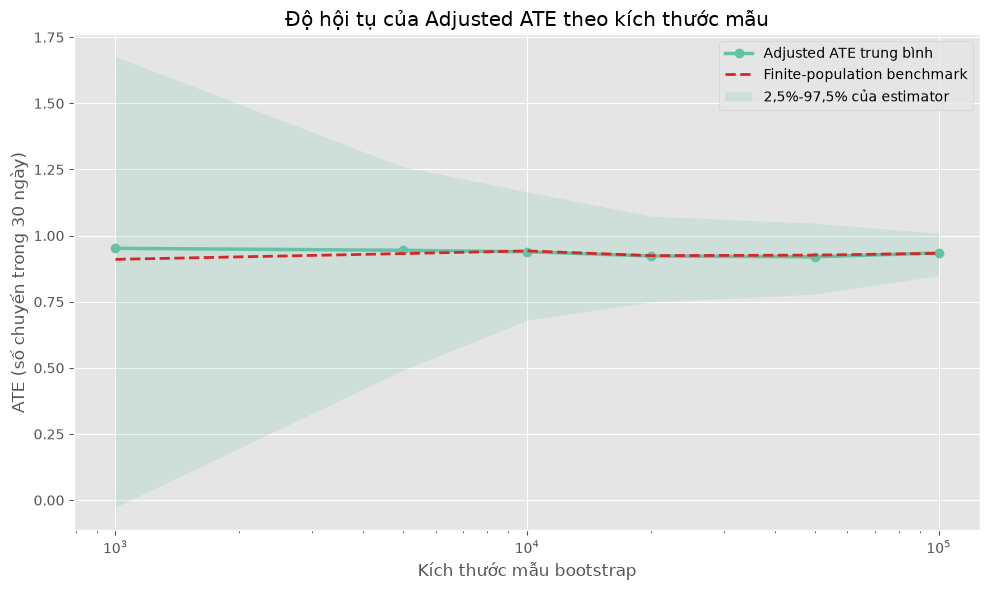

In [3]:
sample_sizes = [1_000, 5_000, 10_000, 20_000, 50_000, 100_000]
n_scale_runs = 100
rng = np.random.default_rng(20260820)
scale_rows = []

for n in sample_sizes:
    for run in range(n_scale_runs):
        result = draw_trial(rng, n=n, treatment_probability=0.5)
        result.update({"sample_size": n, "run": run + 1})
        scale_rows.append(result)

scale_trials = pd.DataFrame(scale_rows)
scale_trials["covered"] = (
    (scale_trials["ci_low"] <= scale_trials["truth"])
    & (scale_trials["ci_high"] >= scale_trials["truth"])
)
scale_summary = (
    scale_trials.groupby("sample_size", as_index=False)
    .agg(
        mean_estimated_ate=("ate", "mean"),
        mean_truth=("truth", "mean"),
        estimator_sd=("ate", "std"),
        mean_hc1_se=("se", "mean"),
        coverage_95=("covered", "mean"),
        q025=("ate", lambda x: x.quantile(0.025)),
        q975=("ate", lambda x: x.quantile(0.975)),
    )
)
display(scale_summary.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    scale_summary["sample_size"],
    scale_summary["mean_estimated_ate"],
    marker="o",
    linewidth=2.5,
    label="Adjusted ATE trung bình",
)
ax.plot(
    scale_summary["sample_size"],
    scale_summary["mean_truth"],
    linestyle="--",
    linewidth=2,
    color="#D62728",
    label="Finite-population benchmark",
)
ax.fill_between(
    scale_summary["sample_size"],
    scale_summary["q025"],
    scale_summary["q975"],
    alpha=0.18,
    label="2,5%-97,5% của estimator",
)
ax.set_xscale("log")
ax.set_xlabel("Kích thước mẫu bootstrap")
ax.set_ylabel("ATE (số chuyến trong 30 ngày)")
ax.set_title("Độ hội tụ của Adjusted ATE theo kích thước mẫu")
ax.legend()
fig.tight_layout()
fig.savefig(IMAGE_DIR / "week6_stress_test_3.png", dpi=180, bbox_inches="tight")
plt.show()

## 2. A/A Test: True Effect = 0

Trong null scenario, cả treatment và control đều nhận outcome `Y0`; treatment label vẫn được randomize 50/50. Notebook chạy 5.000 lần, mỗi lần 2.000 quan sát, rồi tính False Positive Rate tại `alpha = 5%`.

In [4]:
n_aa_runs = 5_000
aa_sample_size = 2_000
aa_rng = np.random.default_rng(20260821)
aa_rows = []

for run in range(n_aa_runs):
    result = draw_trial(
        aa_rng,
        n=aa_sample_size,
        treatment_probability=0.5,
        null_effect=True,
    )
    aa_rows.append(result)

aa_trials = pd.DataFrame(aa_rows)
false_positive_rate = float((aa_trials["p_value"] < 0.05).mean())
fpr_ci = stats.binomtest(
    int((aa_trials["p_value"] < 0.05).sum()),
    n=n_aa_runs,
    p=0.05,
).proportion_ci(confidence_level=0.95)

print(f"A/A runs: {n_aa_runs:,}")
print(f"False Positive Rate: {false_positive_rate:.2%}")
print(f"95% binomial CI của observed FPR: [{fpr_ci.low:.2%}, {fpr_ci.high:.2%}]")
print(f"Mean estimated ATE under null: {aa_trials['ate'].mean():.4f}")

A/A runs: 5,000
False Positive Rate: 5.04%
95% binomial CI của observed FPR: [4.45%, 5.68%]
Mean estimated ATE under null: -0.0013


## 3. Treatment ratio 50/50 so với 10/90

Mỗi trial đều gán treatment mới và dựng lại outcome bằng `Y1` hoặc `Y0` tương ứng. Vì vậy treatment label và outcome luôn nhất quán.

Hai thiết kế có cùng sample size 20.000 và cùng estimator. Kỳ vọng chính: 10/90 không tạo bias có hệ thống nhưng làm standard error và variance lớn hơn.

,design,mean_estimated_ate,mean_truth,bias,estimator_sd,mean_hc1_se,coverage_95,treated_share
0,10/90,0.9401,0.9347,0.0053,0.1573,0.1617,0.9700,0.1000
1,50/50,0.9351,0.9356,-0.0004,0.0932,0.0952,0.9833,0.5004


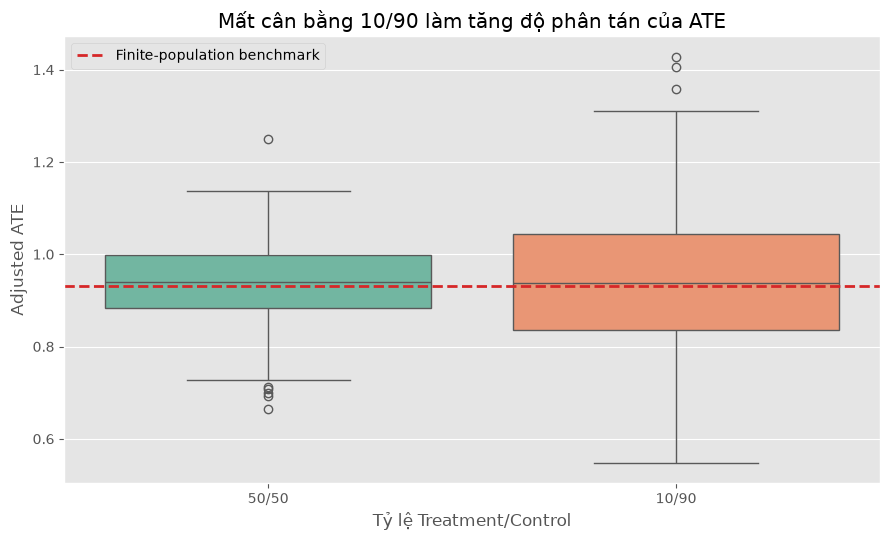

In [5]:
n_ratio_runs = 300
ratio_sample_size = 20_000
ratio_rng = np.random.default_rng(20260822)
ratio_rows = []

for label, probability in [("50/50", 0.5), ("10/90", 0.1)]:
    for run in range(n_ratio_runs):
        result = draw_trial(
            ratio_rng,
            n=ratio_sample_size,
            treatment_probability=probability,
        )
        result.update({"design": label, "run": run + 1})
        ratio_rows.append(result)

ratio_trials = pd.DataFrame(ratio_rows)
ratio_trials["covered"] = (
    (ratio_trials["ci_low"] <= ratio_trials["truth"])
    & (ratio_trials["ci_high"] >= ratio_trials["truth"])
)
ratio_trials["error"] = ratio_trials["ate"] - ratio_trials["truth"]
ratio_summary = (
    ratio_trials.groupby("design", as_index=False)
    .agg(
        mean_estimated_ate=("ate", "mean"),
        mean_truth=("truth", "mean"),
        bias=("error", "mean"),
        estimator_sd=("ate", "std"),
        mean_hc1_se=("se", "mean"),
        coverage_95=("covered", "mean"),
        treated_share=("treated_share", "mean"),
    )
)
display(ratio_summary.round(4))

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=ratio_trials, x="design", y="ate", hue="design", palette="Set2", ax=ax, legend=False)
ax.axhline(finite_population_ate, color="#D62728", linestyle="--", linewidth=2, label="Finite-population benchmark")
ax.set_xlabel("Tỷ lệ Treatment/Control")
ax.set_ylabel("Adjusted ATE")
ax.set_title("Mất cân bằng 10/90 làm tăng độ phân tán của ATE")
ax.legend()
fig.tight_layout()
fig.savefig(IMAGE_DIR / "week6_stress_test_4.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. Mean-zero Gaussian Noise

Kịch bản noise giữ treatment 50/50 và thêm `N(0, 1)` vào outcome quan sát. Mỗi trial dùng cùng sample và treatment assignment cho bản gốc và bản có noise để đo trực tiếp phần uncertainty tăng thêm.

,scenario,mean_estimated_ate,mean_truth,bias,estimator_sd,mean_hc1_se,coverage_95
0,Gaussian noise SD=1,0.9294,0.9318,-0.0024,0.0923,0.0962,1.0
1,Không thêm noise,0.9291,0.9318,-0.0028,0.0907,0.0952,1.0


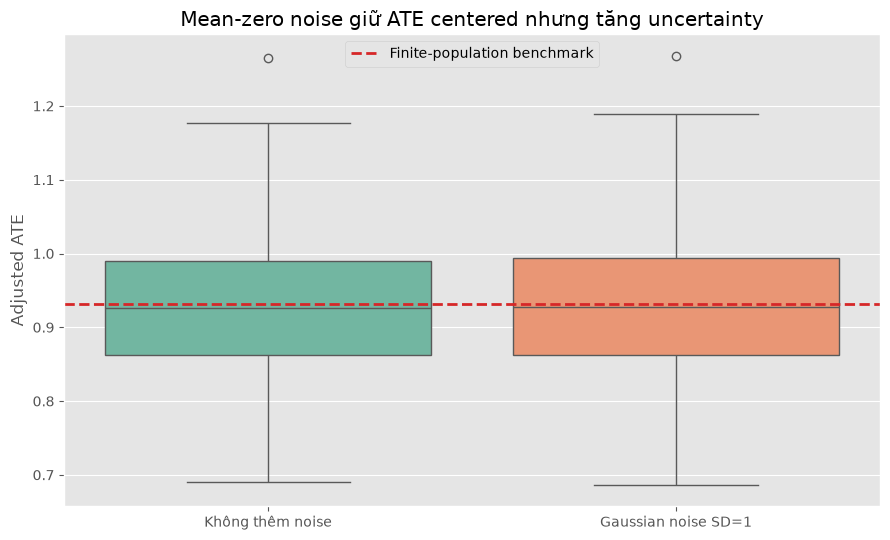

In [6]:
n_noise_runs = 300
noise_sample_size = 20_000
noise_sd = 1.0
noise_rng = np.random.default_rng(20260823)
noise_rows = []

for run in range(n_noise_runs):
    index = noise_rng.integers(0, len(df), size=noise_sample_size)
    sample = df.iloc[index]
    treatment = noise_rng.binomial(1, 0.5, size=noise_sample_size)
    y0 = sample["Y0"].to_numpy(dtype=float)
    y1 = sample["Y1"].to_numpy(dtype=float)
    base_outcome = np.where(treatment == 1, y1, y0)
    baseline = sample["monthly_rides_history"].to_numpy(dtype=float)
    truth = float(np.mean(y1 - y0))

    for scenario, outcome in [
        ("Không thêm noise", base_outcome),
        ("Gaussian noise SD=1", base_outcome + noise_rng.normal(0.0, noise_sd, size=noise_sample_size)),
    ]:
        result = estimate_ate_hc1(outcome, treatment, baseline)
        result.update({"scenario": scenario, "truth": truth, "run": run + 1})
        noise_rows.append(result)

noise_trials = pd.DataFrame(noise_rows)
noise_trials["covered"] = (
    (noise_trials["ci_low"] <= noise_trials["truth"])
    & (noise_trials["ci_high"] >= noise_trials["truth"])
)
noise_trials["error"] = noise_trials["ate"] - noise_trials["truth"]
noise_summary = (
    noise_trials.groupby("scenario", as_index=False)
    .agg(
        mean_estimated_ate=("ate", "mean"),
        mean_truth=("truth", "mean"),
        bias=("error", "mean"),
        estimator_sd=("ate", "std"),
        mean_hc1_se=("se", "mean"),
        coverage_95=("covered", "mean"),
    )
)
display(noise_summary.round(4))

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=noise_trials, x="scenario", y="ate", hue="scenario", palette="Set2", ax=ax, legend=False)
ax.axhline(finite_population_ate, color="#D62728", linestyle="--", linewidth=2, label="Finite-population benchmark")
ax.set_xlabel("")
ax.set_ylabel("Adjusted ATE")
ax.set_title("Mean-zero noise giữ ATE centered nhưng tăng uncertainty")
ax.legend()
fig.tight_layout()
fig.savefig(IMAGE_DIR / "week6_stress_test_5.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Xuất artifact dùng chung cho Report, PPT và Dashboard

Các số liệu dưới đây là nguồn chính thức của báo cáo Tuần 6. Không chép số thủ công từ output cell sang tài liệu.

In [7]:
def row_to_dict(frame, key_column):
    return {
        str(row[key_column]): {
            key: float(value)
            for key, value in row.items()
            if key != key_column
        }
        for row in frame.to_dict(orient="records")
    }


metrics = {
    "source_notebook": "notebooks/week6_stress_test/1_stress_test.ipynb",
    "seed_version": "20260820-20260823",
    "population_rows": int(len(df)),
    "dgp_expected_ate": dgp_expected_ate,
    "finite_population_ate": finite_population_ate,
    "estimator": "OLS: Y ~ Treatment + monthly_rides_history, HC1 standard errors",
    "scale_up": {
        "runs_per_sample_size": n_scale_runs,
        "results": row_to_dict(scale_summary, "sample_size"),
    },
    "aa_test": {
        "runs": n_aa_runs,
        "sample_size_per_run": aa_sample_size,
        "alpha": 0.05,
        "false_positive_rate": false_positive_rate,
        "fpr_ci_low": float(fpr_ci.low),
        "fpr_ci_high": float(fpr_ci.high),
        "mean_estimated_ate": float(aa_trials["ate"].mean()),
    },
    "treatment_ratio": {
        "runs_per_design": n_ratio_runs,
        "sample_size_per_run": ratio_sample_size,
        "results": row_to_dict(ratio_summary, "design"),
    },
    "noise": {
        "runs_per_scenario": n_noise_runs,
        "sample_size_per_run": noise_sample_size,
        "noise_sd": noise_sd,
        "results": row_to_dict(noise_summary, "scenario"),
    },
    "scope": "Synthetic robustness under tested scenarios; not production validation.",
}

with open(OUT_DIR / "week6_stress_test_metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics, file, ensure_ascii=False, indent=2)

scale_summary.to_csv(OUT_DIR / "week6_scale_summary.csv", index=False)
ratio_summary.to_csv(OUT_DIR / "week6_ratio_summary.csv", index=False)
noise_summary.to_csv(OUT_DIR / "week6_noise_summary.csv", index=False)

print(json.dumps(metrics, ensure_ascii=False, indent=2))

{
  "source_notebook": "notebooks/week6_stress_test/1_stress_test.ipynb",
  "seed_version": "20260820-20260823",
  "population_rows": 20000,
  "dgp_expected_ate": 0.79999937,
  "finite_population_ate": 0.93095,
  "estimator": "OLS: Y ~ Treatment + monthly_rides_history, HC1 standard errors",
  "scale_up": {
    "runs_per_sample_size": 100,
    "results": {
      "1000": {
        "mean_estimated_ate": 0.9519972096469406,
        "mean_truth": 0.91018,
        "estimator_sd": 0.420579092474789,
        "mean_hc1_se": 0.42488270816942914,
        "coverage_95": 0.98,
        "q025": -0.02904173247667182,
        "q975": 1.6756257808932145
      },
      "5000": {
        "mean_estimated_ate": 0.9445545579647492,
        "mean_truth": 0.9320780000000001,
        "estimator_sd": 0.18402562692579447,
        "mean_hc1_se": 0.18994440068975776,
        "coverage_95": 0.97,
        "q025": 0.4890399563636724,
        "q975": 1.258421210837038
      },
      "10000": {
        "mean_estimated_

## Kết luận đúng phạm vi

- OLS HC1 bám finite-population benchmark trong các sample-size scenarios đã thử.
- A/A False Positive Rate cần nằm gần alpha 5%, không cần bằng đúng 5%.
- Thiết kế 10/90 chủ yếu làm tăng variance và standard error; nó không tự tạo bias nếu randomization và outcome được dựng đúng.
- Mean-zero noise độc lập không tạo directional bias theo kỳ vọng, nhưng làm tăng uncertainty.
- Đây là kiểm tra trong synthetic sandbox. Nó chưa bao phủ logging failure, non-compliance, interference, spillover hay distribution shift production.